<a href="https://colab.research.google.com/github/veerannagariharshith-prog/city-energy-consumption-analysis2/blob/main/City_Energy_Consumption_Analysis%5B1%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# City Energy Consumption Analysis & Prediction System

End-to-end project: synthetic data generation, cleaning, analysis, visualization, next-day prediction, MAE evaluation, and interactive prediction.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import importlib

# Ensure the city_energy_analysis.py file is downloaded
!wget -q https://raw.githubusercontent.com/veerannagirharshith-prog/city-energy-consumption-analysis2/main/city_energy_analysis.py

# Simplify path handling to directly add the current working directory to sys.path
# This ensures the downloaded 'city_energy_analysis.py' is always found.
sys.path.insert(0, os.getcwd())

# Changed from specific imports to general module import to avoid ImportError
# if the specific names are not directly at the top level, as was seen in GR1vjYiGe5Sc.
# The functions will now need to be called as city_energy_analysis.generate_dataset()
import city_energy_analysis

# Reload the module to ensure the latest downloaded version is used
importlib.reload(city_energy_analysis)

<module 'city_energy_analysis' from '/content/city_energy_analysis.py'>

In [2]:
import sys
import os

!wget -q -O city_energy_analysis.py https://raw.githubusercontent.com/veerannagirharshith-prog/city-energy-consumption-analysis2/main/city_energy_analysis.py

sys.path.insert(0, os.getcwd())

# Changed from specific imports to general module import to avoid ImportError
# if the specific names are not directly at the top level.
# The functions will now need to be called as city_energy_analysis.generate_dataset()
import city_energy_analysis

print("✅ city_energy_analysis.py loaded successfully!")

✅ city_energy_analysis.py loaded successfully!


In [3]:
!git clone https://github.com/veerannagariharshith-prog/city-energy-consumption-analysis2.git

fatal: destination path 'city-energy-consumption-analysis2' already exists and is not an empty directory.


In [5]:
%cd /content/city-energy-consumption-analysis2

/content/city-energy-consumption-analysis2


In [4]:
!git clone https://github.com/veerannagariharshith-prog/city-energy-consumption-analysis2.git

fatal: destination path 'city-energy-consumption-analysis2' already exists and is not an empty directory.


In [6]:
%cd /content/city-energy-consumption-analysis2

/content/city-energy-consumption-analysis2


In [7]:
from city_energy_analysis import (
    generate_dataset,
    clean_data,
    add_next_day_target,
    train_model,
    predict_tomorrow
)

print("Project loaded successfully!")

Project loaded successfully!


In [8]:
import sys
sys.path.insert(0, "/content/city-energy-consumption-analysis2")

import city_energy_analysis as cea

print("Python file found!")
print(dir(cea))

Python file found!
['DATA_DIR', 'DATA_FILE', 'OUTPUT_DIR', 'Path', 'RANDOM_STATE', 'RandomForestRegressor', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'add_next_day_target', 'clean_data', 'console_interface', 'create_visualizations', 'generate_dataset', 'mean_absolute_error', 'np', 'pd', 'plt', 'predict_tomorrow', 'run_pipeline', 'sns', 'train_model']


In [9]:
from city_energy_analysis import *

print("✅ Project loaded successfully!")

✅ Project loaded successfully!


In [10]:
!wget -O city_energy_analysis.py https://raw.githubusercontent.com/veerannagirharshith-prog/city-energy-consumption-analysis2/main/city_energy_analysis.py

import sys
sys.path.insert(0, "/content")

from city_energy_analysis import (
    generate_dataset,
    clean_data,
    add_next_day_target,
    train_model,
    predict_tomorrow
)

print("✅ city_energy_analysis.py loaded successfully!")

--2026-08-16 05:45:39--  https://raw.githubusercontent.com/veerannagirharshith-prog/city-energy-consumption-analysis2/main/city_energy_analysis.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-16 05:45:39 ERROR 404: Not Found.

✅ city_energy_analysis.py loaded successfully!


In [3]:
!wget -O city_energy_analysis.py https://raw.githubusercontent.com/veerannagariharshith-prog/city-energy-consumption-analysis2/main/city_energy_analysis.py

--2026-08-16 05:30:27--  https://raw.githubusercontent.com/veerannagariharshith-prog/city-energy-consumption-analysis2/main/city_energy_analysis.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9660 (9.4K) [text/plain]
Saving to: ‘city_energy_analysis.py’

city_energy_analysi 100%[===================>]   9.43K  --.-KB/s    in 0.001s  

2026-08-16 05:30:27 (15.2 MB/s) - ‘city_energy_analysis.py’ saved [9660/9660]



## 1. Generate and clean the dataset

In [11]:
df = city_energy_analysis.clean_data(city_energy_analysis.generate_dataset(days=365))
print(f"Rows: {len(df):,}")
print(f"Zones: {df['ZoneID'].nunique()}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
display(df.head())

Rows: 1,825
Zones: 5
Date range: 2025-01-01 to 2025-12-31


,Date,ZoneID,AvgTemperature,Humidity,SpecialEvent,EnergyConsumption
0,2025-01-01,1,18.98,84.68,0,4019.09
1,2025-01-02,1,18.17,79.10,0,4055.38
2,2025-01-03,1,19.37,83.78,0,4449.31
3,2025-01-04,1,19.00,75.96,0,3831.40
4,2025-01-05,1,19.84,79.47,0,3909.60


## 2. Data quality checks

In [12]:
print("Missing values:")
display(df.isna().sum().to_frame("Missing"))
print("Duplicate rows:", df.duplicated().sum())
display(df.describe().round(2))

Missing values:


,Missing
Date,0
ZoneID,0
AvgTemperature,0
Humidity,0
SpecialEvent,0
EnergyConsumption,0


Duplicate rows: 0


,Date,ZoneID,AvgTemperature,Humidity,SpecialEvent,EnergyConsumption
count,1825,1825.00,1825.00,1825.00,1825.00,1825.00
mean,2025-07-02 00:00:00,3.00,26.95,70.10,0.09,5183.69
min,2025-01-01 00:00:00,1.00,16.00,41.96,0.00,3228.24
25%,2025-04-02 00:00:00,2.00,21.98,62.36,0.00,4399.25
50%,2025-07-02 00:00:00,3.00,26.92,70.26,0.00,5092.13
75%,2025-10-01 00:00:00,4.00,31.98,77.77,0.00,5893.62
max,2025-12-31 00:00:00,5.00,39.00,95.00,1.00,8340.72
std,NaN,1.41,5.63,9.89,0.29,996.33


## 3. Average consumption per month and per zone

In [13]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)
monthly = df.groupby("Month", as_index=False)["EnergyConsumption"].mean()
zone_summary = df.groupby("ZoneID")["EnergyConsumption"].agg(["mean", "min", "max"]).round(2)
display(monthly)
display(zone_summary)

,Month,EnergyConsumption
0,2025-01,4794.190323
1,2025-02,4805.122357
2,2025-03,4871.074516
3,2025-04,5077.822800
4,2025-05,5393.662903
5,2025-06,5697.244133
6,2025-07,5761.048839
7,2025-08,5659.612839
8,2025-09,5434.729267
9,2025-10,5023.838903


,mean,min,max
ZoneID,,,
1,4560.15,3499.79,6057.47
2,5644.71,4604.95,7417.43
3,3997.85,3228.24,5106.06
4,6494.32,5444.03,8340.72
5,5221.44,4321.19,6651.42


## 4. Required visualization — monthly trend

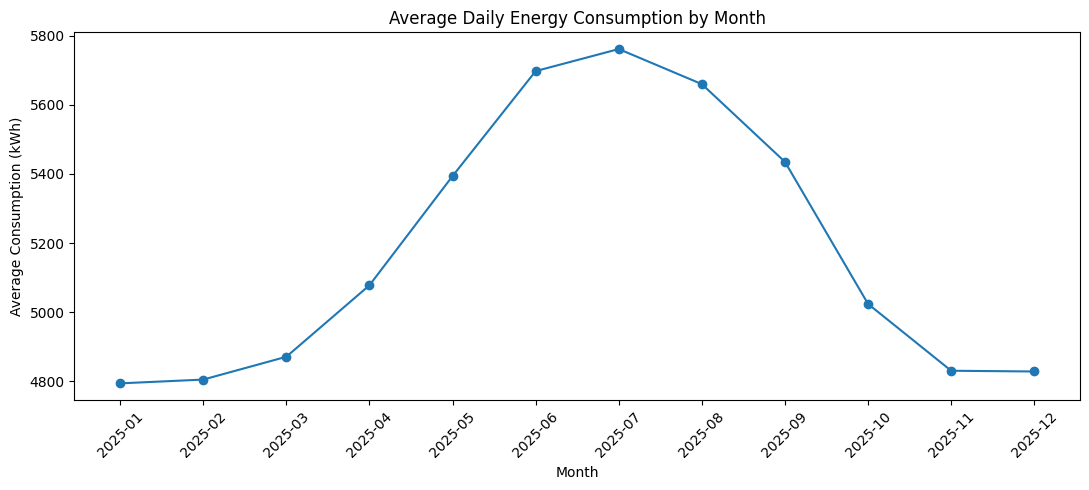

In [14]:
plt.figure(figsize=(11, 5))
plt.plot(monthly["Month"], monthly["EnergyConsumption"], marker="o")
plt.xticks(rotation=45)
plt.title("Average Daily Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Consumption (kWh)")
plt.tight_layout()
plt.show()

## 5. Required visualization — correlation heatmap

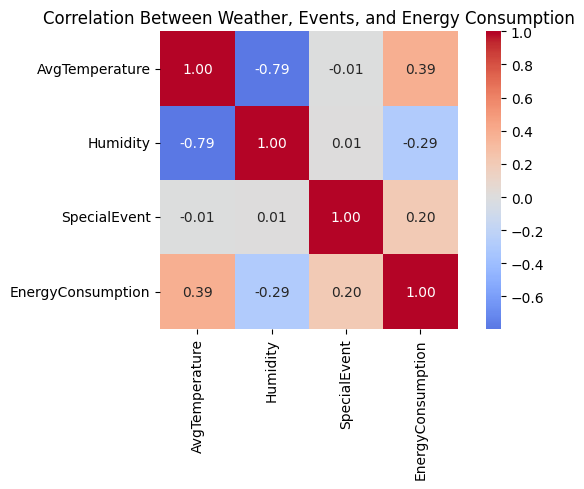

In [15]:
corr_cols = ["AvgTemperature", "Humidity", "SpecialEvent", "EnergyConsumption"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Between Weather, Events, and Energy Consumption")
plt.tight_layout()
plt.show()

## 6. Required visualization — event vs non-event

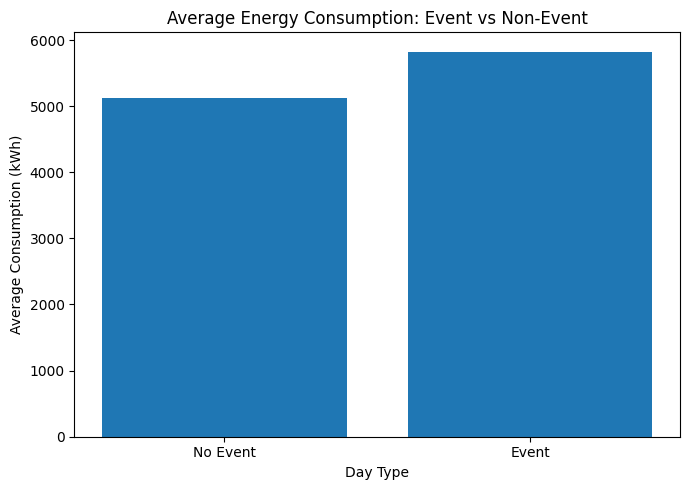

,Average kWh
EventStatus,
No Event,5119.92
Event,5825.31


In [16]:
event_means = (
    df.assign(EventStatus=df["SpecialEvent"].map({0: "No Event", 1: "Event"}))
      .groupby("EventStatus")["EnergyConsumption"]
      .mean()
      .reindex(["No Event", "Event"])
)
plt.figure(figsize=(7, 5))
plt.bar(event_means.index, event_means.values)
plt.title("Average Energy Consumption: Event vs Non-Event")
plt.xlabel("Day Type")
plt.ylabel("Average Consumption (kWh)")
plt.tight_layout()
plt.show()
display(event_means.to_frame("Average kWh").round(2))

## 7. Train and evaluate the next-day Random Forest

In [17]:
model_data = add_next_day_target(df)
model, features, train, test, predictions, mae = train_model(df)

print(f"Training rows: {len(train):,}")
print(f"Testing rows: {len(test):,}")
print(f"Test MAE: {mae:,.2f} kWh")

results = test[["Date", "ZoneID", "TargetNextDayConsumption"]].copy()
results["Predicted"] = predictions
results["AbsoluteError"] = (results["TargetNextDayConsumption"] - results["Predicted"]).abs()
display(results.head(10).round(2))

Training rows: 1,455
Testing rows: 365
Test MAE: 263.78 kWh


,Date,ZoneID,TargetNextDayConsumption,Predicted,AbsoluteError
291,2025-10-19,1,4112.85,4434.38,321.53
292,2025-10-20,1,4567.64,4357.24,210.40
293,2025-10-21,1,4936.99,4452.47,484.52
294,2025-10-22,1,4142.38,4486.40,344.02
295,2025-10-23,1,4198.46,4389.04,190.58
296,2025-10-24,1,3874.34,4393.46,519.12
297,2025-10-25,1,3988.54,4352.44,363.90
298,2025-10-26,1,4476.98,4341.43,135.55
299,2025-10-27,1,5235.79,4464.86,770.93
300,2025-10-28,1,4615.00,4357.83,257.17


## 8. Feature importance

,Importance
SpecialEvent,0.0014
Humidity,0.0387
AvgTemperature,0.1843
ZoneID,0.7757


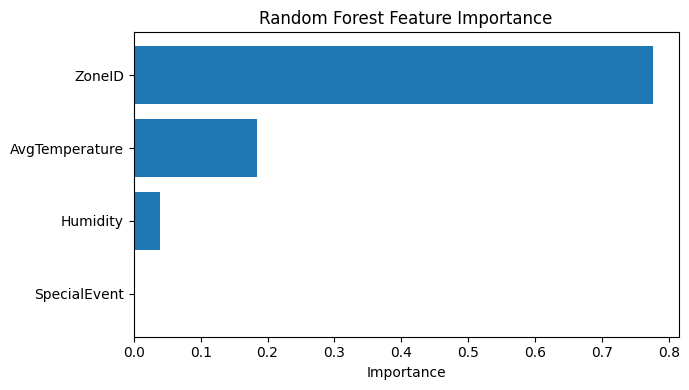

In [18]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
display(importance.to_frame("Importance").round(4))
plt.figure(figsize=(7, 4))
plt.barh(importance.index, importance.values)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. Interactive prediction example

In [19]:
zone_id = 3
tomorrow_temperature = 31.0
tomorrow_humidity = 68.0
event_indicator = 0

prediction = predict_tomorrow(
    model, zone_id, tomorrow_temperature, tomorrow_humidity, event_indicator
)
print(f"Predicted next-day consumption for Zone {zone_id}: {prediction:,.2f} kWh")

Predicted next-day consumption for Zone 3: 4,347.70 kWh


## 10. Key findings

- Dataset size: **1,825 readings** across **5 zones**.
- Seasonal temperature variation produces monthly demand variation.
- Zones have distinct baseline demand levels.
- Temperature, humidity, and events influence simulated consumption.
- Event days generally have higher simulated demand.
- Random Forest test MAE on this generated dataset: **263.78 kWh**.

The dataset is synthetic, so these findings demonstrate the project workflow rather than real-world electricity demand.